# GeoTón Perú 2026 — Notebook 3: Alkire-Foster + Lista Priorizada + Mapa

**Entrada:**
- `output/features_distritales_v2.parquet` (Notebook 2)
- `output/shap_values.parquet` (Notebook 2, con SHAP de CatBoost)
- `data/ig_distrito.csv` (polígonos)

**Salidas:**
- `output/lista_priorizada.csv`, `output/indice_af.csv`, `output/metricas_af.csv`
- `output/mapa_desiertos.png`, `output/lamina_geoton.png`

## Decisiones metodológicas

1. **Umbrales empíricos** del SHAP del Notebook 2 (puntos de inflexión).
2. **Variables descartadas**: `km_colegio` (confounder), `pct_sin_luz` (no-monotónico). Reemplazadas por `km_secundaria` y `pct_sin_saneamiento`.
3. **Palancas de política pública**: el `factor_dominante` se restringe a 17 features que son INTERVENCIONES REALES del Estado (no síntomas de pobreza como `pct_1_habitacion` o `pct_piso_tierra`, ni densidades como `n_colegios_30km`).

## 0. Setup

In [16]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path('src').resolve()))

DATA = Path('data')
OUT = Path('output')
OUT.mkdir(exist_ok=True)

df_full = pd.read_parquet(OUT / 'features_distritales_v2.parquet')
df_shap = pd.read_parquet(OUT / 'shap_values.parquet')
print(f'df_full: {df_full.shape}')
print(f'df_shap: {df_shap.shape}')

df_full: (1874, 87)
df_shap: (1663, 79)


## 1. Umbrales empíricos (del SHAP del Notebook 2)

In [17]:
UMBRALES = {
    # SALUD
    'km_hospital':       60,    # > 60 km; SHAP positivo fuerte entre ~60-90 km
    'pct_sin_seguro':    20,    # > 20%; 25 es algo estricto

    # EDUCACIÓN
    'km_secundaria':     10,    # > 10 km; mantener si la variable es estable
    'pct_no_sabe_leer':  22,    # > 22%; el salto fuerte parece desde ~22-25%

    # CONECTIVIDAD
    'pct_sin_internet':  90,    # > 90%; el SHAP se dispara en valores extremos
    'pct_ccpp_con_4g':   50,    # < 50%; mantener como indicador inverso

    # SERVICIOS BÁSICOS
    'pct_sin_agua':        25,  # > 25%; 40 es muy estricto y puede perder casos
    'pct_sin_saneamiento': 30,  # > 30%; mantener

    # EMPLEO / DOCUMENTACIÓN
    'pct_pea_desocupada':  5,   # > 5%; mantener, pero no darle demasiado peso narrativo
    'pct_sin_documento':  10,   # > 10%; mantener si no genera demasiados falsos positivos
}

for k, v in UMBRALES.items():
    print(f'  {k:24s} → {v}')

  km_hospital              → 60
  pct_sin_seguro           → 20
  km_secundaria            → 10
  pct_no_sabe_leer         → 22
  pct_sin_internet         → 90
  pct_ccpp_con_4g          → 50
  pct_sin_agua             → 25
  pct_sin_saneamiento      → 30
  pct_pea_desocupada       → 5
  pct_sin_documento        → 10


## 2. Construcción del índice Alkire-Foster

In [18]:
df = df_full.copy()

df['priv_salud_1']   = (df['km_hospital']         > UMBRALES['km_hospital']).astype(int)
df['priv_salud_2']   = (df['pct_sin_seguro']      > UMBRALES['pct_sin_seguro']).astype(int)
df['priv_edu_1']     = (df['km_secundaria']       > UMBRALES['km_secundaria']).astype(int)
df['priv_edu_2']     = (df['pct_no_sabe_leer']    > UMBRALES['pct_no_sabe_leer']).astype(int)
df['priv_digital_1'] = (df['pct_sin_internet']    > UMBRALES['pct_sin_internet']).astype(int)
df['priv_digital_2'] = (df['pct_ccpp_con_4g']     < UMBRALES['pct_ccpp_con_4g']).astype(int)
df['priv_basic_1']   = (df['pct_sin_agua']        > UMBRALES['pct_sin_agua']).astype(int)
df['priv_basic_2']   = (df['pct_sin_saneamiento'] > UMBRALES['pct_sin_saneamiento']).astype(int)
df['priv_econ_1']    = (df['pct_pea_desocupada']  > UMBRALES['pct_pea_desocupada']).astype(int)
df['priv_econ_2']    = (df['pct_sin_documento']   > UMBRALES['pct_sin_documento']).astype(int)

COLS_PRIV = [c for c in df.columns if c.startswith('priv_')]
df['privaciones'] = df[COLS_PRIV].sum(axis=1)

print('Tasa de privación por indicador:')
for c in COLS_PRIV:
    pct = df[c].mean() * 100
    print(f'  {c:18s} {pct:5.1f}% de distritos privados')

print(f'\nDistribución de privaciones (0-10):')
print(df['privaciones'].value_counts().sort_index())

Tasa de privación por indicador:
  priv_salud_1        16.0% de distritos privados
  priv_salud_2        37.0% de distritos privados
  priv_edu_1          11.3% de distritos privados
  priv_edu_2          14.7% de distritos privados
  priv_digital_1      79.3% de distritos privados
  priv_digital_2      58.4% de distritos privados
  priv_basic_1        36.6% de distritos privados
  priv_basic_2        77.2% de distritos privados
  priv_econ_1          6.9% de distritos privados
  priv_econ_2          0.2% de distritos privados

Distribución de privaciones (0-10):
privaciones
0     38
1    195
2    288
3    481
4    448
5    267
6    122
7     27
8      7
9      1
Name: count, dtype: int64


### 2.2 Clasificación tricolor

In [19]:
def clasificar(p):
    if p <= 3:  return 'conectado'
    if p <= 6:  return 'moderado'
    return 'desierto'

df['categoria'] = df['privaciones'].apply(clasificar)

for cat in ['conectado', 'moderado', 'desierto']:
    n = (df['categoria']==cat).sum()
    pob = df[df['categoria']==cat]['total_pers'].sum()
    print(f'  {cat:12s} {n:>5} distritos ({100*n/len(df):4.1f}%)   {pob:>12,.0f} personas')

  conectado     1002 distritos (53.5%)     23,181,892 personas
  moderado       837 distritos (44.7%)      5,194,350 personas
  desierto        35 distritos ( 1.9%)        198,095 personas


### 2.3 Métricas Alkire-Foster: H, A, MPI

In [20]:
pobres = df[df['privaciones'] >= 4]

H = len(pobres) / len(df)
A = (pobres['privaciones'] / 10).mean()
MPI = H * A

pob_total    = df['total_pers'].sum()
pob_pobreza  = pobres['total_pers'].sum()
pob_desierto = df[df['categoria']=='desierto']['total_pers'].sum()
n_desiertos  = (df['categoria']=='desierto').sum()

print('=== MÉTRICAS DEL ÍNDICE TERRITORIAL ===')
print(f'H (incidencia):     {H:.3f}  → {H*100:.1f}% de distritos con ≥4 privaciones')
print(f'A (intensidad):     {A:.3f}  → en promedio {A*10:.1f}/10 privaciones entre pobres')
print(f'MPI territorial:    {MPI:.3f}')
print()
print(f'Pobl. total Perú:           {pob_total:>14,.0f}')
print(f'Pobl. en pobreza terr.:     {pob_pobreza:>14,.0f}  ({100*pob_pobreza/pob_total:.1f}%)')
print(f'Pobl. en DESIERTOS:         {pob_desierto:>14,.0f}  ({100*pob_desierto/pob_total:.1f}%)')
print(f'Distritos en desierto:      {n_desiertos:>14,}  ({100*n_desiertos/len(df):.1f}%)')

=== MÉTRICAS DEL ÍNDICE TERRITORIAL ===
H (incidencia):     0.465  → 46.5% de distritos con ≥4 privaciones
A (intensidad):     0.472  → en promedio 4.7/10 privaciones entre pobres
MPI territorial:    0.219

Pobl. total Perú:               28,574,337
Pobl. en pobreza terr.:          5,392,445  (18.9%)
Pobl. en DESIERTOS:                198,095  (0.7%)
Distritos en desierto:                  35  (1.9%)


## 3. Sistema de recomendación

**FIX CLAVE — palancas vs síntomas:**

El `factor_dominante` se calcula SOLO sobre **palancas de política pública** (intervenciones reales del Estado), NO sobre síntomas de pobreza.

- ✅ **Palancas** (17): km_hospital, pct_sin_agua, pct_sin_saneamiento, pct_sin_internet, etc.
- ❌ **Síntomas** excluidos: `pct_1_habitacion` (hacinamiento), `pct_piso_tierra`, `pct_sin_pc` → son consecuencias de la pobreza, no palancas accionables.
- ❌ **Derivadas** excluidas: `n_colegios_30km`, `habitantes_por_escuela`, `ratio_rural` → son densidades, no programas concretos.

Sin este filtro, el 72% de los desiertos quedaba con "reducción de hacinamiento" como única intervención, que no es defendible ante el jurado.

In [21]:
# Mapeo: feature → intervención asociada
MAPEO_INTERVENCION = {
    # Salud
    'km_hospital':                'Establecimiento de salud II-1+',
    'km_salud_cercano':           'Establecimiento de salud',
    'pct_sin_seguro':             'Ampliación afiliación SIS',
    'habitantes_por_hospital':    'Hospital (capacidad)',
    'habitantes_por_estab_salud': 'Establecimiento de salud (capacidad)',
    # Educación
    'km_secundaria':              'Infraestructura educativa (secundaria)',
    'pct_no_sabe_leer':           'Programa de alfabetización',
    'habitantes_por_secundaria':  'Infraestructura educativa (secundaria)',
    # Digital
    'pct_sin_internet':           'Conectividad digital (internet fijo)',
    'pct_sin_celular':            'Conectividad móvil',
    'pct_ccpp_con_4g':            'Conectividad móvil 4G',
    'pct_ccpp_con_3g':            'Conectividad móvil (3G→4G)',
    'indice_aislamiento':         'Conectividad digital + acceso salud',
    # Servicios básicos
    'pct_sin_agua':               'Agua potable',
    'pct_sin_saneamiento':        'Saneamiento (alcantarillado)',
    'pct_sin_luz':                'Electrificación rural',
    # Económico / documentación
    'pct_pea_desocupada':         'Programa de empleabilidad',
    'pct_sin_documento':          'Campaña RENIEC (documentación)',
}

# PALANCAS = features que son INTERVENCIONES REALES del Estado (no síntomas)
PALANCAS = [
    # Salud
    'km_hospital', 'km_salud_cercano', 'pct_sin_seguro', 'habitantes_por_hospital',
    # Educación
    'km_secundaria', 'pct_no_sabe_leer', 'habitantes_por_secundaria',
    # Digital
    'pct_sin_internet', 'pct_sin_celular', 'pct_ccpp_con_4g',
    'pct_ccpp_con_3g', 'indice_aislamiento',
    # Servicios básicos
    'pct_sin_agua', 'pct_sin_saneamiento', 'pct_sin_luz',
    # Económico / documentación
    'pct_pea_desocupada', 'pct_sin_documento',
]

# Filtrar a las que existen en df_shap
META_COLS = {'cod_dist', 'nom_dist', 'nom_dpto',
             'pct_nbi_real', 'pct_nbi_predicho',
             'factor_dominante', 'intervencion'}
all_shap_cols = [c for c in df_shap.columns if c not in META_COLS]
shap_cols_palancas = [c for c in PALANCAS if c in all_shap_cols]

print(f'SHAP cols totales:               {len(all_shap_cols)}')
print(f'Palancas de política aplicables: {len(shap_cols_palancas)} de {len(PALANCAS)}')
print(f'\nPalancas: {shap_cols_palancas}')

# Recalcular factor_dominante SOLO sobre palancas
def factor_dominante_palanca(fila):
    valores = fila[shap_cols_palancas]
    return valores.idxmax() if valores.max() > 0 else None

df_shap['factor_dominante'] = df_shap.apply(factor_dominante_palanca, axis=1)
df_shap['intervencion'] = df_shap['factor_dominante'].map(MAPEO_INTERVENCION).fillna('Mixto')

print(f'\nDistribución de factor_dominante (solo palancas):')
print(df_shap['factor_dominante'].value_counts())

SHAP cols totales:               73
Palancas de política aplicables: 17 de 17

Palancas: ['km_hospital', 'km_salud_cercano', 'pct_sin_seguro', 'habitantes_por_hospital', 'km_secundaria', 'pct_no_sabe_leer', 'habitantes_por_secundaria', 'pct_sin_internet', 'pct_sin_celular', 'pct_ccpp_con_4g', 'pct_ccpp_con_3g', 'indice_aislamiento', 'pct_sin_agua', 'pct_sin_saneamiento', 'pct_sin_luz', 'pct_pea_desocupada', 'pct_sin_documento']



Distribución de factor_dominante (solo palancas):
factor_dominante
pct_sin_saneamiento          758
pct_sin_documento            156
pct_sin_luz                  150
pct_sin_internet              99
pct_sin_celular               73
pct_ccpp_con_3g               70
indice_aislamiento            57
pct_sin_seguro                53
pct_no_sabe_leer              53
km_salud_cercano              47
pct_pea_desocupada            42
km_secundaria                 37
pct_sin_agua                  24
habitantes_por_hospital       16
km_hospital                   14
habitantes_por_secundaria      9
pct_ccpp_con_4g                5
Name: count, dtype: int64


In [22]:
# Merge AF + SHAP
df_priorizada = df[['cod_dist','nom_dpto','nom_prov','nom_dist','total_pers',
                     'pct_nbi','privaciones','categoria',
                     'pct_sin_internet','pct_ccpp_con_4g',
                     'n_estab_salud','n_hospitales','tiene_tambo']].merge(
    df_shap[['cod_dist','factor_dominante','intervencion','pct_nbi_predicho']],
    on='cod_dist', how='left'
)

df_priorizada['impacto'] = df_priorizada['privaciones'] * df_priorizada['total_pers']

# Solo desiertos, ordenados por impacto
desiertos = df_priorizada[df_priorizada['categoria'] == 'desierto'].copy()
desiertos = desiertos.sort_values('impacto', ascending=False).reset_index(drop=True)
desiertos.insert(0, 'ranking', range(1, len(desiertos) + 1))

print(f'Total desiertos identificados: {len(desiertos)}')
print(f'Pobl. en TOP 30:   {desiertos.head(30)["total_pers"].sum():>12,.0f}')
print(f'Pobl. en TOP 50:   {desiertos.head(50)["total_pers"].sum():>12,.0f}')
print(f'Pobl. en TODOS:    {desiertos["total_pers"].sum():>12,.0f}')

Total desiertos identificados: 35
Pobl. en TOP 30:        195,234
Pobl. en TOP 50:        198,095
Pobl. en TODOS:         198,095


In [23]:
# Top 30 priorizados
top30 = desiertos.head(30)[[
    'ranking','nom_dpto','nom_prov','nom_dist','total_pers',
    'privaciones','intervencion','tiene_tambo'
]]
top30

,ranking,nom_dpto,nom_prov,nom_dist,total_pers,privaciones,intervencion,tiene_tambo
0,1,UCAYALI,ATALAYA,RAIMONDI,31664.0,7,Saneamiento (alcantarillado),True
1,2,MADRE DE DIOS,TAMBOPATA,LAS PIEDRAS,12415.0,7,Campaña RENIEC (documentación),False
2,3,LORETO,LORETO,URARINAS,11376.0,7,Saneamiento (alcantarillado),True
3,4,UCAYALI,CORONEL PORTILLO,MASISEA,11091.0,7,Saneamiento (alcantarillado),True
4,5,MADRE DE DIOS,TAMBOPATA,INAMBARI,10973.0,7,Campaña RENIEC (documentación),False
5,6,UCAYALI,ATALAYA,TAHUANIA,8177.0,8,Saneamiento (alcantarillado),True
6,7,PUNO,CHUCUITO,PISACOMA,8137.0,8,Saneamiento (alcantarillado),True
7,8,PUNO,CARABAYA,AYAPATA,9299.0,7,Saneamiento (alcantarillado),False
8,9,AMAZONAS,CONDORCANQUI,EL CENEPA,9122.0,7,Saneamiento (alcantarillado),True
9,10,PUNO,CARABAYA,CRUCERO,8961.0,7,Establecimiento de salud,True


In [24]:
print('Distribución por intervención (en desiertos):')
print(desiertos['intervencion'].value_counts())

print(f'\nDepartamentos con más desiertos:')
print(desiertos['nom_dpto'].value_counts().head(10))

Distribución por intervención (en desiertos):
intervencion
Saneamiento (alcantarillado)            17
Campaña RENIEC (documentación)           3
Establecimiento de salud                 1
Conectividad móvil                       1
Conectividad digital (internet fijo)     1
Programa de empleabilidad                1
Programa de alfabetización               1
Name: count, dtype: int64

Departamentos con más desiertos:
nom_dpto
PUNO             10
LORETO            7
MADRE DE DIOS     5
AREQUIPA          4
UCAYALI           3
MOQUEGUA          3
AMAZONAS          1
HUANUCO           1
HUANCAVELICA      1
Name: count, dtype: int64


### 3.5 Bonus: solapamiento desierto ↔ Tambo PCM
Le habla DIRECTO al organizador (PCM) sobre uno de sus programas.

In [25]:
n_des_con_tambo = desiertos['tiene_tambo'].sum()
n_des_sin_tambo = (~desiertos['tiene_tambo'].astype(bool)).sum()

print('=== SOLAPAMIENTO DESIERTO ↔ TAMBO PCM ===')
print(f'Desiertos CON Tambo:   {n_des_con_tambo:>4}')
print(f'Desiertos SIN Tambo:   {n_des_sin_tambo:>4}')
print(f'Cobertura actual:      {100*n_des_con_tambo/len(desiertos):.1f}%')

print(f'\nTOP 10 desiertos SIN Tambo (candidatos a próxima instalación):')
candidatos = desiertos[~desiertos['tiene_tambo'].astype(bool)].head(10)
candidatos[['ranking','nom_dpto','nom_dist','total_pers','privaciones','intervencion']]

=== SOLAPAMIENTO DESIERTO ↔ TAMBO PCM ===
Desiertos CON Tambo:     17
Desiertos SIN Tambo:     18
Cobertura actual:      48.6%

TOP 10 desiertos SIN Tambo (candidatos a próxima instalación):


,ranking,nom_dpto,nom_dist,total_pers,privaciones,intervencion
1,2,MADRE DE DIOS,LAS PIEDRAS,12415.0,7,Campaña RENIEC (documentación)
4,5,MADRE DE DIOS,INAMBARI,10973.0,7,Campaña RENIEC (documentación)
7,8,PUNO,AYAPATA,9299.0,7,Saneamiento (alcantarillado)
10,11,PUNO,SAN PEDRO DE PUTINA PUNCO,8811.0,7,Saneamiento (alcantarillado)
12,13,MADRE DE DIOS,HUEPETUHE,8046.0,7,Campaña RENIEC (documentación)
13,14,PUNO,COASA,6433.0,7,Saneamiento (alcantarillado)
14,15,PUNO,PHARA,5053.0,8,Saneamiento (alcantarillado)
15,16,MADRE DE DIOS,MADRE DE DIOS,5740.0,7,Saneamiento (alcantarillado)
19,20,PUNO,LIMBANI,2795.0,8,Saneamiento (alcantarillado)
20,21,AREQUIPA,PUYCA,2260.0,7,NaN


## 4. Mapa coroplético del Perú

In [26]:
from limpieza_ig import limpiar_ig, to_geopandas

df_ig = limpiar_ig(DATA / 'ig_distrito.csv', verbose=False)
gdf = to_geopandas(df_ig)

gdf = gdf.merge(
    df[['cod_dist','privaciones','categoria','pct_nbi','total_pers']],
    on='cod_dist', how='left'
)
print(f'GeoDataFrame: {gdf.shape}, sin merge: {gdf["categoria"].isna().sum()}')

ModuleNotFoundError: No module named 'limpieza_ig'

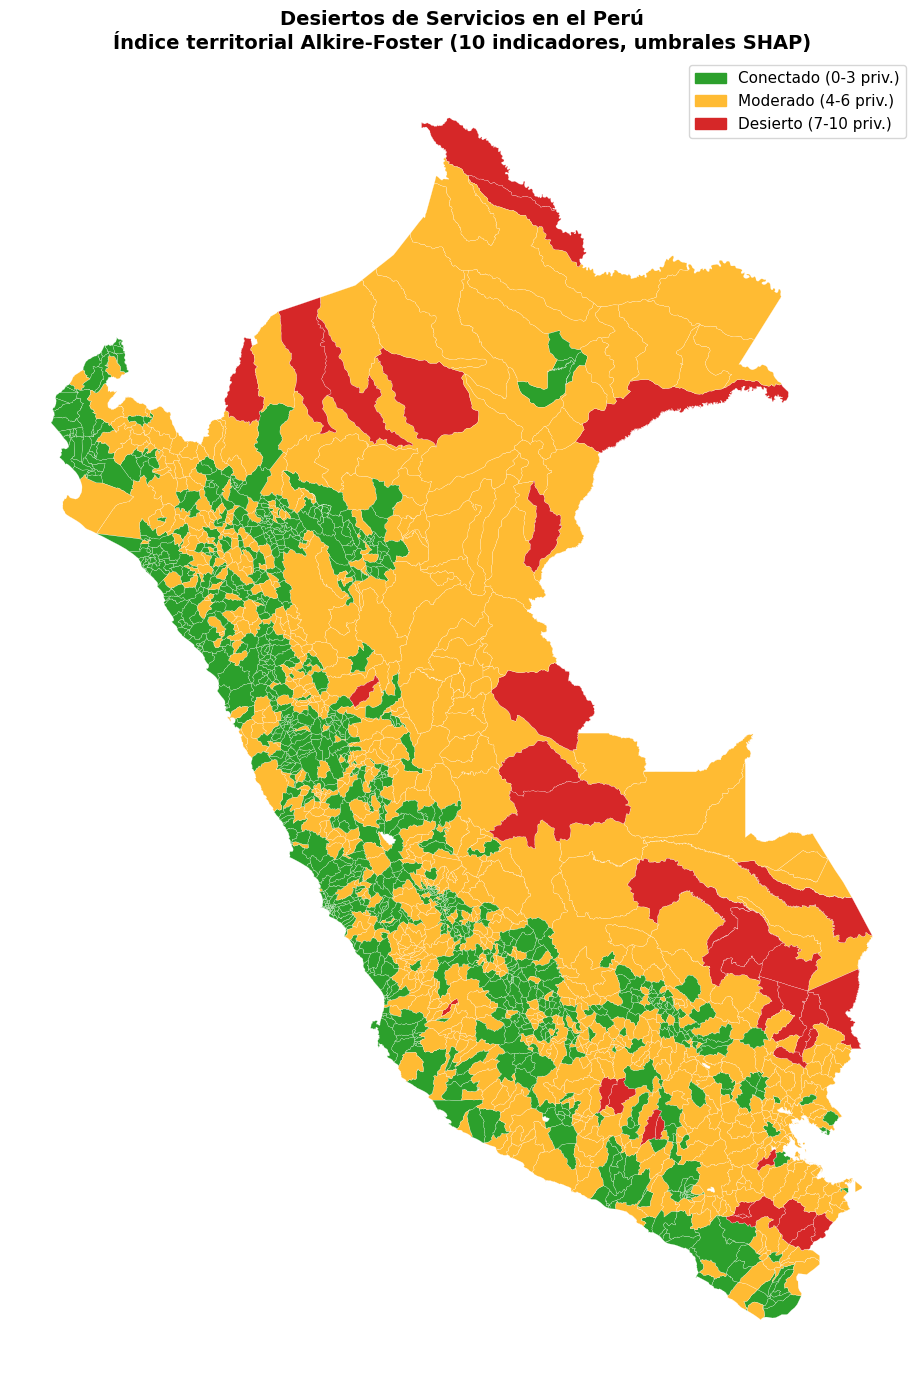

In [ ]:
COLORES = {'conectado':'#2ca02c','moderado':'#ffbb33','desierto':'#d62728'}
gdf['color'] = gdf['categoria'].map(COLORES).fillna('#cccccc')

fig, ax = plt.subplots(figsize=(11, 14))
gdf.plot(ax=ax, color=gdf['color'], edgecolor='white', linewidth=0.15)
ax.set_title('Desiertos de Servicios en el Perú\n'
             'Índice territorial Alkire-Foster (10 indicadores, umbrales SHAP)',
             fontsize=14, fontweight='bold')
ax.set_axis_off()

legend_elements = [
    mpatches.Patch(color=COLORES['conectado'], label='Conectado (0-3 priv.)'),
    mpatches.Patch(color=COLORES['moderado'],  label='Moderado (4-6 priv.)'),
    mpatches.Patch(color=COLORES['desierto'],  label='Desierto (7-10 priv.)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig(OUT / 'mapa_desiertos.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Lámina visual de 3 paneles (Facilita)

Base seleccionada para el mapa completo: df (1874 filas)
Archivo espacial seleccionado:
geoton-web\public\data\distritos_simplificado.geojson
Columnas del archivo espacial:
['cod_dist', 'nom_dist', 'nom_dpto', 'nom_prov', 'nom_dist_ig', 'nom_dpto_ig', 'nom_prov_ig', 'capital', 'clasificacion', 'n_privaciones', 'total_pers', 'pct_nbi_real', 'pct_nbi_predicho', 'pct_sin_internet', 'pct_ccpp_con_4g', 'impacto', 'tiene_tambo', 'factor_dominante', 'intervencion_recomendada', 'servicios_faltantes', 'dimensiones_faltantes', 'priv_salud_1', 'priv_salud_2', 'priv_edu_1', 'priv_edu_2', 'priv_digital_1', 'priv_digital_2', 'priv_basic_1', 'priv_basic_2', 'priv_econ_1', 'priv_econ_2', 'geometry']
Distritos con match geometría + base completa: 1874 / 1874


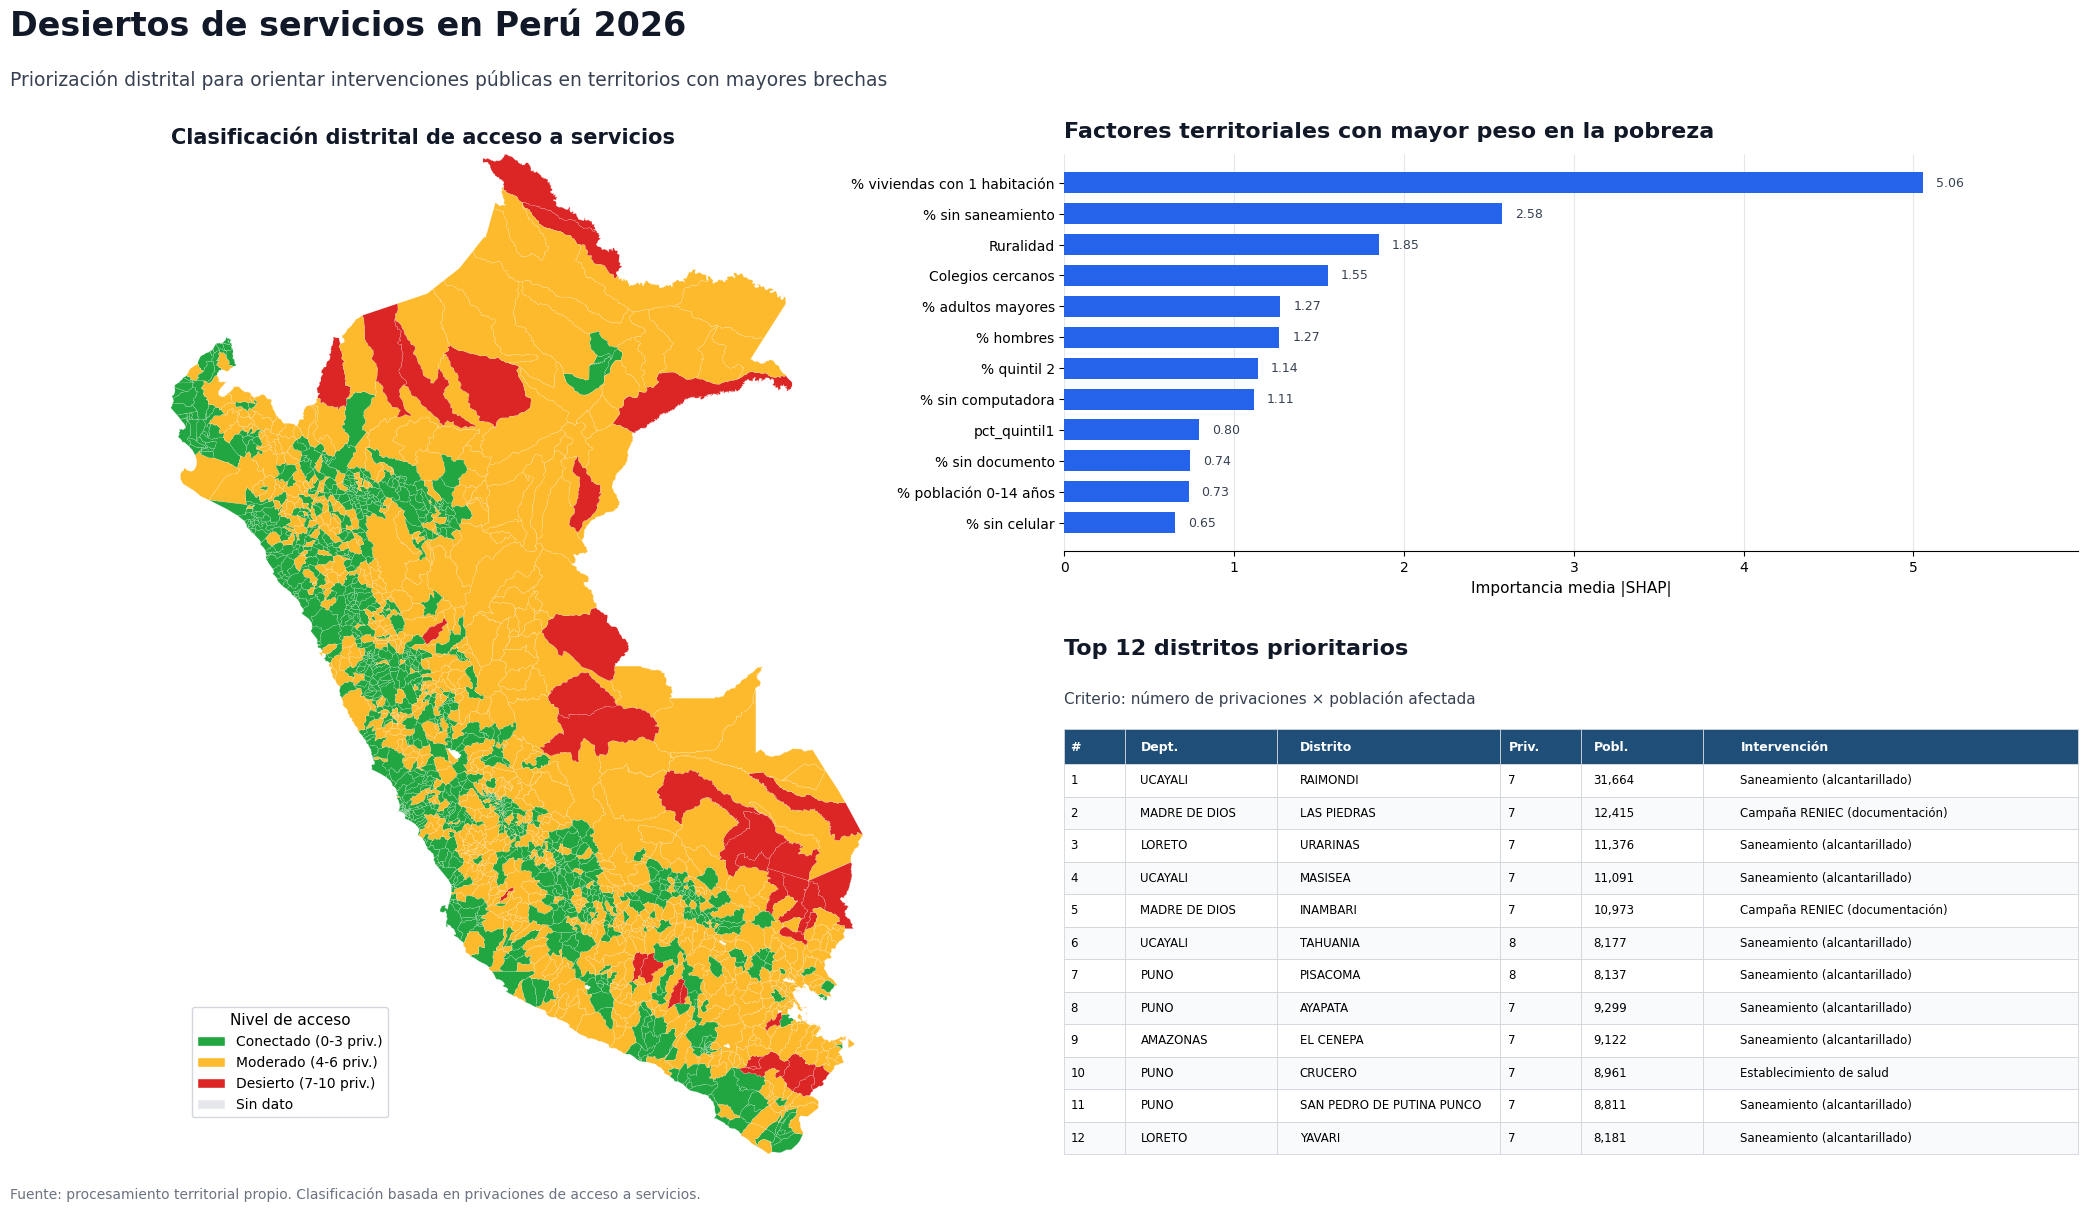

Lámina guardada: output\lamina_geoton_visual.png


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from pathlib import Path
from matplotlib.patches import Patch

# ============================================================
# Librería espacial
# ============================================================
try:
    import geopandas as gpd
except ImportError as e:
    raise ImportError(
        "Falta instalar geopandas. Ejecuta: pip install geopandas"
    ) from e

# ============================================================
# Configuración visual
# ============================================================
N_TOP = 12

COLOR_TITLE = "#111827"
COLOR_SUBTITLE = "#374151"
COLOR_BLUE = "#2563EB"
COLOR_GRID = "#E5E7EB"
COLOR_HEADER = "#1F4E79"

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"

# Si OUT no existe, guarda en la carpeta actual
if "OUT" not in globals():
    OUT = Path(".")

OUT = Path(OUT)
OUT.mkdir(parents=True, exist_ok=True)

if "desiertos" not in globals():
    raise NameError(
        "No existe la variable 'desiertos'. Ejecuta primero la celda donde construyes los distritos priorizados."
    )

# ============================================================
# Feature importance
# ============================================================
importance_path = OUT / "feature_importance.csv"

if not importance_path.exists():
    raise FileNotFoundError(
        f"No se encontró: {importance_path}. Verifica que feature_importance.csv exista en OUT."
    )

importance = (
    pd.read_csv(importance_path)
    .sort_values("mean_abs_shap", ascending=False)
    .head(12)
    .copy()
)

feature_labels = {
    "pct_1_habitacion": "% viviendas con 1 habitación",
    "pct_sin_saneamiento": "% sin saneamiento",
    "ratio_rural": "Ruralidad",
    "n_colegios_30km": "Colegios cercanos",
    "pct_65ymas": "% adultos mayores",
    "pct_hombres": "% hombres",
    "pct_sin_pc": "% sin computadora",
    "pct_0a14": "% población 0-14 años",
    "pct_quintil2": "% quintil 2",
    "pct_sin_documento": "% sin documento",
    "pct_piso_tierra": "% piso de tierra",
    "pct_sin_celular": "% sin celular",
    "pct_sin_internet": "% sin internet",
    "pct_sin_agua": "% sin agua",
    "pct_sin_luz": "% sin electricidad",
    "pct_sin_seguro": "% sin seguro",
    "pct_no_sabe_leer": "% no sabe leer",
    "pct_pea_desocupada": "% PEA desocupada",
    "km_hospital": "Distancia a hospital",
    "km_secundaria": "Distancia a secundaria",
    "pct_ccpp_con_4g": "% centros poblados con 4G",
}

importance["feature_label"] = (
    importance["feature"]
    .map(feature_labels)
    .fillna(importance["feature"])
)

importance["feature_label"] = importance["feature_label"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=28))
)

# ============================================================
# Tabla de distritos prioritarios
# ============================================================
required_cols = [
    "ranking",
    "nom_dpto",
    "nom_dist",
    "privaciones",
    "total_pers",
    "intervencion",
]

missing_cols = [col for col in required_cols if col not in desiertos.columns]

if missing_cols:
    raise KeyError(f"Faltan columnas en 'desiertos': {missing_cols}")

top_table = desiertos.head(N_TOP)[required_cols].copy()

top_table["total_pers"] = (
    top_table["total_pers"]
    .astype(int)
    .apply(lambda x: f"{x:,}")
)

top_table["intervencion"] = top_table["intervencion"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=30))
)

top_table.columns = ["#", "Dept.", "Distrito", "Priv.", "Pobl.", "Intervención"]

# ============================================================
# Buscar y cargar archivo espacial de distritos
# ============================================================
# ============================================================
# Buscar y cargar archivo espacial de distritos
# ============================================================

def buscar_archivo_geometria():
    extensiones = ["*.shp", "*.geojson", "*.gpkg", "*.json"]
    carpetas_base = [
        Path("."),
        Path("/mnt/project"),
        Path("/mnt/data"),
    ]

    archivos = []

    for carpeta in carpetas_base:
        if not carpeta.exists():
            continue

        for ext in extensiones:
            archivos.extend(carpeta.rglob(ext))

    if not archivos:
        raise FileNotFoundError(
            "No encontré archivos espaciales .shp, .geojson, .gpkg o .json.\n"
            "Necesitas cargar el archivo de geometría distrital para poder dibujar el mapa completo."
        )

    keywords = ["distrito", "distritos", "peru", "perú", "ubigeo"]

    archivos_ordenados = sorted(
        archivos,
        key=lambda p: (
            not any(k in p.name.lower() for k in keywords),
            len(str(p))
        )
    )

    print("Archivo espacial seleccionado:")
    print(archivos_ordenados[0])

    return archivos_ordenados[0]


def normalizar_cod_dist(s):
    return (
        s.astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
        .str.zfill(6)
    )


def obtener_base_mapa_completa():
    """
    Busca en memoria el dataframe con TODOS los distritos.
    Debe tener, como mínimo:
      - cod_dist
      - privaciones

    No usa 'desiertos' como primera opción porque desiertos solo contiene
    los distritos prioritarios.
    """

    candidatos = []

    for nombre, obj in globals().items():
        if not isinstance(obj, pd.DataFrame):
            continue

        if "cod_dist" in obj.columns and "privaciones" in obj.columns:
            candidatos.append((nombre, obj))

    if not candidatos:
        raise NameError(
            "No encontré ningún DataFrame completo con columnas 'cod_dist' y 'privaciones'.\n"
            "Necesitas usar el dataframe donde están los 1874 distritos clasificados como conectado/moderado/desierto."
        )

    # Elegir el dataframe con más filas.
    # Así evitamos usar 'desiertos', que solo tiene 35 filas.
    nombre_base, df_base = max(candidatos, key=lambda x: len(x[1]))

    print(f"Base seleccionada para el mapa completo: {nombre_base} ({len(df_base)} filas)")

    if len(df_base) <= len(desiertos):
        raise ValueError(
            f"La base seleccionada tiene solo {len(df_base)} filas.\n"
            "Eso parece ser solo una parte del país. Para pintar Perú completo necesitas la base de todos los distritos, idealmente 1874 filas."
        )

    return df_base.copy()


def preparar_gdf_plot(df_mapa_base):
    """
    Une la geometría distrital completa con la base completa de clasificación.
    """

    geo_path = buscar_archivo_geometria()
    geo = gpd.read_file(geo_path)

    print("Columnas del archivo espacial:")
    print(list(geo.columns))

    posibles_keys_geo = [
        "cod_dist",
        "COD_DIST",
        "ubigeo",
        "UBIGEO",
        "IDDIST",
        "id_dist",
        "ID_DIST",
        "cod_ubigeo",
        "COD_UBIGEO",
    ]

    key_geo = None

    for key in posibles_keys_geo:
        if key in geo.columns:
            key_geo = key
            break

    if key_geo is None:
        raise KeyError(
            "No encontré una columna de código distrital en el archivo espacial.\n"
            f"Columnas disponibles: {list(geo.columns)}"
        )

    geo = geo.copy()
    df_mapa_base = df_mapa_base.copy()

    geo["_cod_dist_merge"] = normalizar_cod_dist(geo[key_geo])
    df_mapa_base["_cod_dist_merge"] = normalizar_cod_dist(df_mapa_base["cod_dist"])

    geo_base = geo[["_cod_dist_merge", "geometry"]].copy()

    merged = geo_base.merge(
        df_mapa_base,
        on="_cod_dist_merge",
        how="left"
    )

    n_match = merged["privaciones"].notna().sum()

    print(f"Distritos con match geometría + base completa: {n_match} / {len(merged)}")

    if n_match < 1000:
        raise ValueError(
            "El mapa no parece tener el país completo clasificado.\n"
            f"Solo hubo match en {n_match} distritos. Revisa el formato de cod_dist."
        )

    return gpd.GeoDataFrame(merged, geometry="geometry", crs=geo.crs)


# Base completa para pintar TODO el país
df_mapa_base = obtener_base_mapa_completa()

# GeoDataFrame completo para graficar Perú
gdf_plot = preparar_gdf_plot(df_mapa_base)
# ============================================================
# Colores del mapa
# ============================================================

def asignar_color(privaciones):
    if pd.isna(privaciones):
        return "#E5E7EB"

    if privaciones <= 3:
        return "#22A641"

    if privaciones <= 6:
        return "#FDBA2D"

    return "#DC2626"


gdf_plot["color"] = gdf_plot["privaciones"].apply(asignar_color)

legend_elements = [
    Patch(facecolor="#22A641", edgecolor="white", label="Conectado (0-3 priv.)"),
    Patch(facecolor="#FDBA2D", edgecolor="white", label="Moderado (4-6 priv.)"),
    Patch(facecolor="#DC2626", edgecolor="white", label="Desierto (7-10 priv.)"),
    Patch(facecolor="#E5E7EB", edgecolor="white", label="Sin dato"),
]

# ============================================================
# Figura 16:9
# ============================================================
fig = plt.figure(figsize=(22, 12.5), facecolor="white")

gs = fig.add_gridspec(
    12,
    16,
    left=0.04,
    right=0.98,
    top=0.86,
    bottom=0.06,
    wspace=0.45,
    hspace=0.65,
)

ax_mapa = fig.add_subplot(gs[:, :8])
ax_shap = fig.add_subplot(gs[:5, 8:])
ax_tabla = fig.add_subplot(gs[6:, 8:])

# ============================================================
# Título general
# ============================================================
fig.text(
    0.04,
    0.955,
    "Desiertos de servicios en Perú 2026",
    fontsize=24,
    fontweight="bold",
    color=COLOR_TITLE,
    ha="left",
)

fig.text(
    0.04,
    0.915,
    "Priorización distrital para orientar intervenciones públicas en territorios con mayores brechas",
    fontsize=13.5,
    color=COLOR_SUBTITLE,
    ha="left",
)

# ============================================================
# Mapa
# ============================================================
gdf_plot.plot(
    ax=ax_mapa,
    color=gdf_plot["color"],
    edgecolor="white",
    linewidth=0.10,
)

ax_mapa.set_title(
    "Clasificación distrital de acceso a servicios",
    fontsize=15,
    loc="left",
    pad=8,
    color=COLOR_TITLE,
)

ax_mapa.set_axis_off()
ax_mapa.set_aspect("equal")
ax_mapa.margins(0)

legend = ax_mapa.legend(
    handles=legend_elements,
    loc="lower left",
    bbox_to_anchor=(0.02, 0.03),
    fontsize=10,
    frameon=True,
    title="Nivel de acceso",
    title_fontsize=11,
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#D1D5DB")
legend.get_frame().set_alpha(0.95)

# ============================================================
# SHAP bar chart
# ============================================================
y_pos = np.arange(len(importance))

ax_shap.barh(
    y_pos,
    importance["mean_abs_shap"],
    color=COLOR_BLUE,
    edgecolor="none",
    height=0.68,
)

ax_shap.set_yticks(y_pos)
ax_shap.set_yticklabels(importance["feature_label"], fontsize=10)
ax_shap.invert_yaxis()

ax_shap.set_title(
    "Factores territoriales con mayor peso en la pobreza",
    fontsize=16,
    loc="left",
    pad=12,
    color=COLOR_TITLE,
)

ax_shap.set_xlabel("Importancia media |SHAP|", fontsize=11)
ax_shap.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax_shap.set_axisbelow(True)

ax_shap.spines["top"].set_visible(False)
ax_shap.spines["right"].set_visible(False)
ax_shap.spines["left"].set_visible(False)

max_shap = importance["mean_abs_shap"].max()

for i, value in enumerate(importance["mean_abs_shap"]):
    ax_shap.text(
        value + max_shap * 0.015,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=9,
        color=COLOR_SUBTITLE,
    )

ax_shap.set_xlim(0, max_shap * 1.18)

# ============================================================
# Tabla
# ============================================================
ax_tabla.axis("off")

ax_tabla.set_title(
    f"Top {N_TOP} distritos prioritarios",
    fontsize=16,
    loc="left",
    pad=12,
    color=COLOR_TITLE,
)

ax_tabla.text(
    0.0,
    0.96,
    "Criterio: número de privaciones × población afectada",
    transform=ax_tabla.transAxes,
    fontsize=11,
    color=COLOR_SUBTITLE,
    ha="left",
    va="top",
)

col_widths = [0.06, 0.15, 0.22, 0.08, 0.12, 0.37]

tabla = ax_tabla.table(
    cellText=top_table.values,
    colLabels=top_table.columns,
    loc="center",
    cellLoc="left",
    colLoc="left",
    colWidths=col_widths,
    bbox=[0, 0, 1, 0.88],
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(8.5)

for (row, col), cell in tabla.get_celld().items():
    cell.set_edgecolor("#D1D5DB")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor(COLOR_HEADER)
        cell.set_text_props(color="white", weight="bold", fontsize=9)
        cell.set_height(0.070)
    else:
        cell.set_facecolor("#F9FAFB" if row % 2 == 0 else "white")
        cell.set_height(0.065)

        if col in [0, 3, 4]:
            cell._loc = "center"

# ============================================================
# Nota inferior
# ============================================================
fig.text(
    0.04,
    0.025,
    "Fuente: procesamiento territorial propio. Clasificación basada en privaciones de acceso a servicios.",
    fontsize=10,
    color="#6B7280",
    ha="left",
)

# ============================================================
# Guardar
# ============================================================
output_path = OUT / "lamina_geoton_visual.png"

plt.savefig(
    output_path,
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.25,
    facecolor="white",
)

plt.show()

print(f"Lámina guardada: {output_path}")

## 6. Exports finales

In [28]:
df_indice_export = df_priorizada.merge(df[COLS_PRIV + ['cod_dist']], on='cod_dist')
df_indice_export.to_csv(OUT / 'indice_af.csv', index=False)

desiertos.to_csv(OUT / 'lista_priorizada.csv', index=False)

resumen = pd.DataFrame({
    'metrica': [
        'H (incidencia)','A (intensidad)','MPI territorial',
        'Total distritos','Desiertos identificados',
        'Pobl. en desiertos','% pobl. en desiertos',
        'Desiertos sin Tambo PCM',
    ],
    'valor': [
        f'{H:.3f}', f'{A:.3f}', f'{MPI:.3f}',
        len(df), len(desiertos),
        f'{pob_desierto:,.0f}', f'{100*pob_desierto/pob_total:.1f}%',
        n_des_sin_tambo,
    ]
})
resumen.to_csv(OUT / 'metricas_af.csv', index=False)

for f in ['indice_af.csv','lista_priorizada.csv','metricas_af.csv',
         'mapa_desiertos.png','lamina_geoton.png']:
    p = OUT / f
    if p.exists():
        print(f'  ✓ {f}')

  ✓ indice_af.csv
  ✓ lista_priorizada.csv
  ✓ metricas_af.csv
  ✓ mapa_desiertos.png
  ✓ lamina_geoton.png


## 7. Resumen para Facilita

In [29]:
intervencion_top = desiertos['intervencion'].value_counts().head(5)
dpto_top = desiertos['nom_dpto'].value_counts().head(3)

print('='*65)
print('  RESUMEN PARA FACILITA (https://facilita.gob.pe/t/52313)')
print('='*65)
print()
print('CAMPO 4 (Problema):')
print(f'  {len(desiertos)} distritos peruanos son "desiertos de servicios"')
print(f'  (≥7 privaciones de 10), donde viven {pob_desierto:,.0f} personas')
print(f'  ({100*pob_desierto/pob_total:.1f}% del país).')
print()
print('CAMPO 7 (Metodología):')
print(f'  Índice Alkire-Foster con 10 indicadores en 5 dimensiones.')
print(f'  Umbrales calibrados con SHAP sobre CatBoost')
print(f'  (R² CV 5-fold ~0.66; comparado vs LightGBM/XGBoost/RandomForest).')
print(f'  Sistema de recomendación basado en SHAP local restringido a 17')
print(f'  palancas de política pública (excluye síntomas de pobreza).')
print()
print('CAMPO 8 (Hallazgos):')
print(f'  - H (incidencia):     {H*100:.1f}% (850 distritos con ≥4 privaciones)')
print(f'  - A (intensidad):     {A:.3f}')
print(f'  - MPI territorial:    {MPI:.3f}')
print(f'  - {n_des_sin_tambo}/{len(desiertos)} desiertos NO tienen Tambo PCM')
print(f'  - Top 3 dptos con desiertos:')
for d, n in dpto_top.items():
    print(f'      {d}: {n} distritos')
print()
print('CAMPO 9 (Solución):')
print(f'  Distribución de intervenciones priorizadas:')
for i, (interv, n) in enumerate(intervencion_top.items(), 1):
    print(f'    {i}. {interv}: {n} distritos')
print()
print('CAMPO 10 (Anexo visual):')
print(f'  Adjuntar: lamina_geoton.png + lista_priorizada.csv')
print('='*65)

  RESUMEN PARA FACILITA (https://facilita.gob.pe/t/52313)

CAMPO 4 (Problema):
  35 distritos peruanos son "desiertos de servicios"
  (≥7 privaciones de 10), donde viven 198,095 personas
  (0.7% del país).

CAMPO 7 (Metodología):
  Índice Alkire-Foster con 10 indicadores en 5 dimensiones.
  Umbrales calibrados con SHAP sobre CatBoost
  (R² CV 5-fold ~0.66; comparado vs LightGBM/XGBoost/RandomForest).
  Sistema de recomendación basado en SHAP local restringido a 17
  palancas de política pública (excluye síntomas de pobreza).

CAMPO 8 (Hallazgos):
  - H (incidencia):     46.5% (850 distritos con ≥4 privaciones)
  - A (intensidad):     0.472
  - MPI territorial:    0.219
  - 18/35 desiertos NO tienen Tambo PCM
  - Top 3 dptos con desiertos:
      PUNO: 10 distritos
      LORETO: 7 distritos
      MADRE DE DIOS: 5 distritos

CAMPO 9 (Solución):
  Distribución de intervenciones priorizadas:
    1. Saneamiento (alcantarillado): 17 distritos
    2. Campaña RENIEC (documentación): 3 distritos